# 06 — Operational Insights
Weekly KPI trends, anomaly-method choice, and structural driver attribution — validating the shipped engine (`app.ai.insights.metrics`). Ops metrics only; no ticket-content root-cause.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))  # backend/ on path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from app.ai.insights import metrics
w = metrics.weekly()
print(f'{len(w)} weeks | {w.index.min().date()} .. {w.index.max().date()}')
w.tail(3)

51 weeks | 2025-07-28 .. 2026-07-13


,volume,breach_rate,handle_time,resolution_time,csat,reopen_rate,backlog
week,,,,,,,
2026-06-29 00:00:00+00:00,135,0.340741,37.911111,492.329545,0.795918,0.051852,2265
2026-07-06 00:00:00+00:00,122,0.409836,35.409836,658.094118,0.744681,0.032787,2302
2026-07-13 00:00:00+00:00,141,0.368794,37.744681,520.854369,0.736842,0.070922,2339


## The seven KPI series

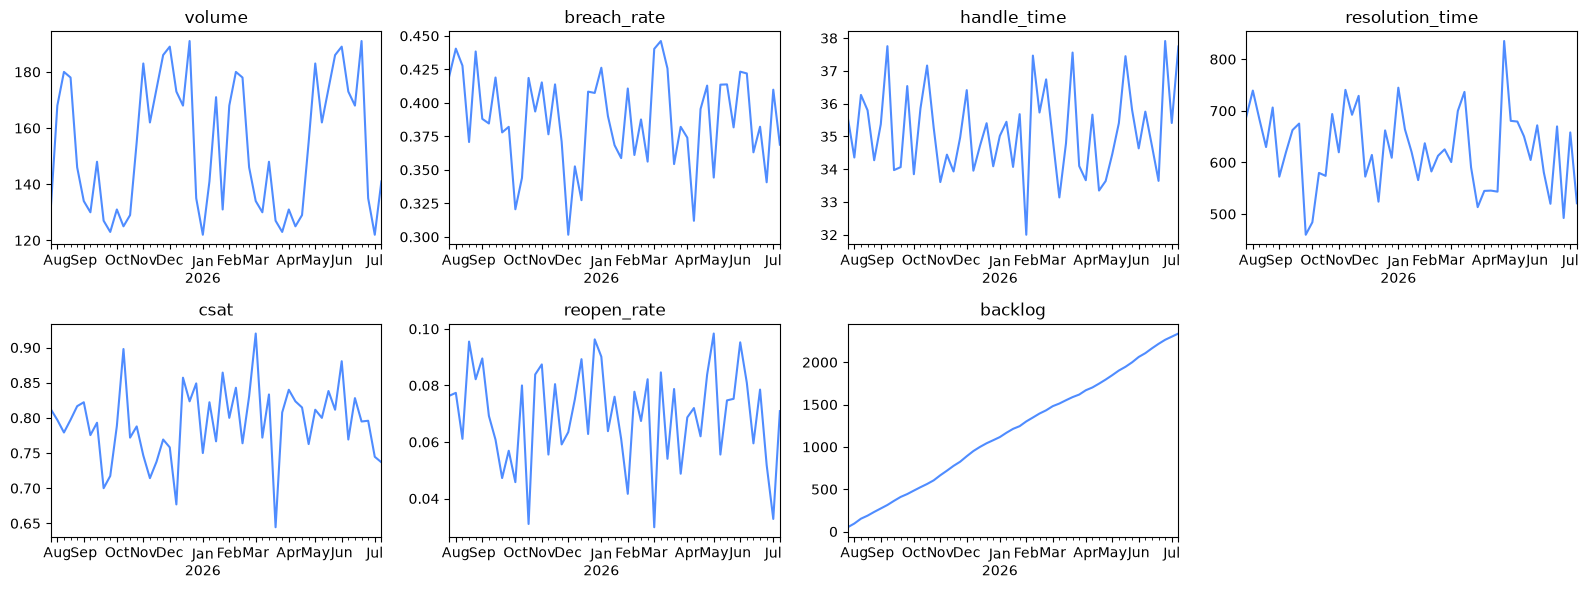

In [2]:
fig, ax = plt.subplots(2, 4, figsize=(16, 6))
for a, m in zip(ax.ravel(), metrics.METRICS):
    w[m].plot(ax=a, color='#4f8cff'); a.set_title(m); a.set_xlabel('')
ax.ravel()[-1].axis('off')
plt.tight_layout(); plt.show()

## Anomaly method: classic z-score vs robust median/MAD
Short 50-week series with a single injected spike — the classic z-score's mean/std are inflated by the spike itself, so a robust modified z-score (median/MAD) is the safer flagger.

injected spike at 2026-01-19
classic |z|>3 flags : [datetime.date(2026, 1, 19)]
robust  MAD    flags: [datetime.date(2026, 1, 19)]


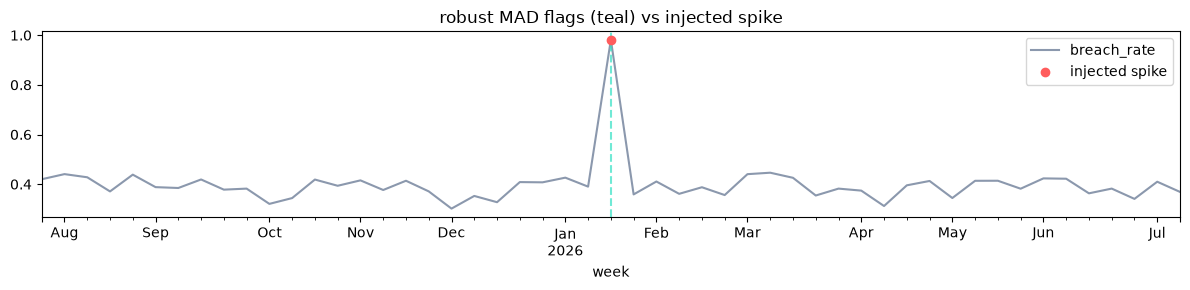

In [3]:
s = w['breach_rate'].copy()
s_spike = s.copy(); wk = s_spike.index[len(s_spike)//2]; s_spike.loc[wk] = s.max()*2.2  # inject one spike
# classic z
z = (s_spike - s_spike.mean())/s_spike.std(); classic = z[z.abs()>3].index
# robust (shipped engine)
robust = metrics.flag_anomalies(s_spike, 3.5).index
print('injected spike at', wk.date())
print('classic |z|>3 flags :', [d.date() for d in classic])
print('robust  MAD    flags:', [d.date() for d in robust])
fig, ax = plt.subplots(figsize=(12,3)); s_spike.plot(ax=ax, color='#8b98ad')
ax.scatter([wk],[s_spike.loc[wk]], color='#ff5c5c', zorder=5, label='injected spike')
for d in robust: ax.axvline(d, color='#34e1c4', ls='--', alpha=.7)
ax.set_title('robust MAD flags (teal) vs injected spike'); ax.legend(); plt.tight_layout(); plt.show()

## Driver attribution reconciles to the pooled delta

breach_rate  total_delta=+0.0053  sum(contributions)=+0.0053  reconciles=True
handle_time  total_delta=+0.7612  sum(contributions)=+0.7612  reconciles=True


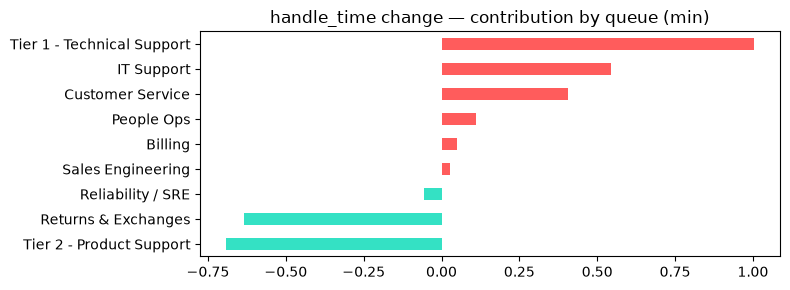

In [4]:
for m in ['breach_rate','handle_time']:
    d = metrics.drivers(m, 'queue', 8)
    seg = sum(x['contribution'] for x in d['segments'])
    print(f"{m:12} total_delta={d['total_delta']:+.4f}  sum(contributions)={seg:+.4f}  reconciles={abs(seg-d['total_delta'])<1e-6}")
d = metrics.drivers('handle_time','queue',8)
seg = pd.Series({x['segment']: x['contribution'] for x in d['segments']}).sort_values()
plt.figure(figsize=(8,3)); seg.plot(kind='barh', color=['#ff5c5c' if v>0 else '#34e1c4' for v in seg])
plt.title('handle_time change — contribution by queue (min)'); plt.tight_layout(); plt.show()

## Decision

In [5]:
anoms = {m: len(metrics.anomalies(m)) for m in metrics.METRICS}
decision = {
  'anomaly_method': 'robust median/MAD (modified z, threshold 3.5)',
  'why': 'classic z-score mean/std are inflated by the anomaly itself on a short series',
  'window': 'last 8 weeks vs prior 8 (weekly)',
  'anomalies_found_on_real_series': anoms,
  'note': 'real (uninjected) series is smooth calibrated seasonality -> few/no statistical anomalies',
  'drivers': 'structural segments only (queue/priority/channel/type), reconcile to the pooled delta',
}
import json; print(json.dumps(decision, indent=2))

{
  "anomaly_method": "robust median/MAD (modified z, threshold 3.5)",
  "why": "classic z-score mean/std are inflated by the anomaly itself on a short series",
  "window": "last 8 weeks vs prior 8 (weekly)",
  "anomalies_found_on_real_series": {
    "volume": 0,
    "breach_rate": 0,
    "handle_time": 0,
    "resolution_time": 0,
    "csat": 0,
    "reopen_rate": 0,
    "backlog": 0
  },
  "note": "real (uninjected) series is smooth calibrated seasonality -> few/no statistical anomalies",
  "drivers": "structural segments only (queue/priority/channel/type), reconcile to the pooled delta"
}
